# ClearBank — Análise Financeira com Python

Notebook do desafio final do módulo. Ele lê o histórico de transações exportado pela equipe de operações (`transacoes.csv`), **valida e limpa** os dados, gera **métricas financeiras mensais**, sinaliza **transações suspeitas**, exibe um **relatório formatado** e salva o resultado em **`relatorio.json`**.

### Instruções — arquivo de entrada

O arquivo `transacoes.csv` precisa estar na mesma pasta do notebook, com as colunas:

| Coluna | Tipo esperado | Regra de validação |
|---|---|---|
| `id` | inteiro | não pode ser vazio nem não numérico; ids repetidos são descartados |
| `data` | texto | formato `AAAA-MM-DD` e data existente |
| `cliente_id` | texto | não pode ser vazio |
| `tipo` | texto | `credito` ou `debito` |
| `valor` | decimal | numérico e maior que 0 |
| `descricao` | texto | livre |
| `categoria` | texto | ex.: salario, compra, transferencia |

O arquivo usado aqui tem **30 linhas**: 20 válidas distribuídas em 4 meses (jan–abr/2026), 3 transações acima de R$ 10.000,00 e **10 linhas inválidas** de propósito, uma para cada regra (valor `abc`, cliente vazio, id vazio, id `X24`, data `05/03/2026`, data `2026-02-30`, tipo `estorno`, valor negativo, valor zero e um id duplicado).

Se o arquivo não existir (por exemplo, ao abrir no Colab sem fazer upload), a célula **0** cria ele com esses dados.

### Ordem do notebook
0. Configuração e arquivo de entrada → 1. Leitura → 2. Validação → 3. Datas → 4. Métricas e suspeitas → 5. JSON → 6. Exibição → **7. Célula de execução principal** → 8. Gráfico (opcional) → 9. pandas (opcional)

## 0. Configuração e arquivo de entrada

In [1]:
import csv
import json
import math
import os
from datetime import date, datetime

CAMINHO_CSV = "transacoes.csv"
CAMINHO_JSON = "relatorio.json"
LIMITE_SUSPEITO = 10000.00
TIPOS_VALIDOS = ("credito", "debito")
FORMATO_DATA = "%Y-%m-%d"

print(f"Configuração carregada | CSV: {CAMINHO_CSV} | JSON: {CAMINHO_JSON} | LIMITE_SUSPEITO: {LIMITE_SUSPEITO}")

Configuração carregada | CSV: transacoes.csv | JSON: relatorio.json | LIMITE_SUSPEITO: 10000.0


In [2]:
CSV_EXEMPLO = """id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-08,CLI002,debito,180.50,Supermercado,compra
3,2026-01-12,CLI003,credito,4200.00,Salário janeiro,salario
4,2026-01-15,CLI001,debito,1250.00,Aluguel,conta
21,2026-01-20,CLI001,debito,abc,Erro de sistema,compra
5,2026-01-22,CLI004,credito,12500.00,Transferência recebida do exterior,transferencia
6,2026-01-28,CLI002,debito,89.90,Assinatura streaming,assinatura
7,2026-02-03,CLI001,credito,3500.00,Salário fevereiro,salario
8,2026-02-07,CLI003,debito,640.00,Compra de eletrônicos,compra
22,2026-02-10,,debito,200.00,Sem cliente,transferencia
9,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
10,2026-02-18,CLI002,debito,320.00,Conta de luz,conta
,2026-02-20,CLI002,debito,75.00,Sem identificador,compra
11,2026-02-25,CLI004,debito,2300.00,Transferência para terceiros,transferencia
26,2026-02-30,CLI001,debito,60.00,Data inexistente,compra
9,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
12,2026-03-02,CLI001,credito,3500.00,Salário março,salario
X24,2026-03-03,CLI003,credito,500.00,ID inválido,transferencia
25,05/03/2026,CLI004,debito,120.00,Data em formato brasileiro,compra
13,2026-03-05,CLI002,credito,2800.00,Salário março,salario
14,2026-03-10,CLI003,debito,99.90,Streaming,assinatura
27,2026-03-12,CLI002,estorno,90.00,Tipo desconhecido,compra
15,2026-03-17,CLI004,debito,450.75,Supermercado,compra
16,2026-03-28,CLI001,debito,11800.00,Entrada de veículo,compra
17,2026-04-01,CLI002,credito,2800.00,Salário abril,salario
28,2026-04-05,CLI003,debito,-150.00,Valor negativo,compra
18,2026-04-09,CLI003,debito,210.30,Farmácia,compra
29,2026-04-11,CLI004,credito,0,Valor zerado,transferencia
19,2026-04-15,CLI001,credito,3500.00,Salário abril,salario
20,2026-04-22,CLI004,debito,1500.00,Transferência PIX,transferencia
"""


def criar_csv_exemplo(caminho=CAMINHO_CSV):
    """Cria o transacoes.csv de teste, sem sobrescrever um arquivo que já exista."""
    if os.path.exists(caminho):
        print(f"'{caminho}' já existe — usando o arquivo atual.")
        return
    with open(caminho, "w", encoding="utf-8", newline="") as arquivo:
        arquivo.write(CSV_EXEMPLO)
    print(f"'{caminho}' criado com {CSV_EXEMPLO.count(chr(10)) - 1} transações.")


criar_csv_exemplo()

'transacoes.csv' já existe — usando o arquivo atual.


## 1. Leitura do arquivo CSV

Leitura com o módulo nativo `csv` (`csv.DictReader`, acesso às colunas pelo nome). Se o arquivo não existir, o `FileNotFoundError` é tratado e a função devolve uma lista vazia em vez de quebrar o programa.

In [3]:
def ler_transacoes(caminho=CAMINHO_CSV):
    """Lê o CSV e devolve a lista de transações brutas (um dicionário por linha)."""
    try:
        with open(caminho, encoding="utf-8", newline="") as arquivo:
            return list(csv.DictReader(arquivo))
    except FileNotFoundError:
        print(f"ERRO: o arquivo '{caminho}' não foi encontrado.")
        return []


print("Função definida: ler_transacoes()")

Função definida: ler_transacoes()


In [4]:
# Teste rápido — leitura
linhas_teste = ler_transacoes()
print(f"Linhas lidas: {len(linhas_teste)}")
print("Primeira linha:", linhas_teste[0])

print("\nArquivo inexistente:")
print("Retorno:", ler_transacoes("arquivo_que_nao_existe.csv"))

Linhas lidas: 30
Primeira linha: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}

Arquivo inexistente:
ERRO: o arquivo 'arquivo_que_nao_existe.csv' não foi encontrado.
Retorno: []


## 2. Validação e limpeza dos dados

Cada regra tem sua própria função pequena. As conversões de `id`, `valor` e `data` ficam dentro de `try/except ValueError`: quando uma linha tem um dado ruim, ela é descartada e o processamento continua normalmente.

`validar_transacao()` devolve uma tupla `(registro, motivo)` — o registro limpo quando a linha é válida, ou o motivo do descarte quando não é.

In [5]:
def obter_campo(linha, campo):
    """Devolve o campo sem espaços extras ('' se estiver vazio ou ausente)."""
    return (linha.get(campo) or "").strip()


def validar_id(texto):
    """Converte o id para inteiro. Retorna None se vazio ou não numérico."""
    try:
        return int(texto)
    except ValueError:
        return None


def validar_data(texto):
    """Converte 'AAAA-MM-DD' para datetime. Retorna None se o formato ou a data forem inválidos."""
    try:
        data = datetime.strptime(texto, FORMATO_DATA)
    except ValueError:
        return None
    # strptime aceita '2026-1-5'; comparar de volta garante o formato exato AAAA-MM-DD
    if data.strftime(FORMATO_DATA) != texto:
        return None
    return data


def validar_valor(texto):
    """Converte o valor para float. Retorna None se não numérico ou <= 0."""
    try:
        valor = float(texto)
    except ValueError:
        return None
    if not math.isfinite(valor) or valor <= 0:  # descarta também 'nan' e 'inf'
        return None
    return valor


print("Funções definidas: obter_campo(), validar_id(), validar_data(), validar_valor()")

Funções definidas: obter_campo(), validar_id(), validar_data(), validar_valor()


In [6]:
def validar_transacao(linha):
    """Valida uma linha do CSV e retorna (registro_limpo, None) ou (None, motivo)."""
    id_transacao = validar_id(obter_campo(linha, "id"))
    if id_transacao is None:
        return None, "id vazio ou não numérico"

    cliente = obter_campo(linha, "cliente_id")
    if not cliente:
        return None, "cliente_id vazio"

    data = validar_data(obter_campo(linha, "data"))
    if data is None:
        return None, "data fora do formato AAAA-MM-DD"

    tipo = obter_campo(linha, "tipo").lower()
    if tipo not in TIPOS_VALIDOS:
        return None, f"tipo inválido ('{tipo}')"

    valor = validar_valor(obter_campo(linha, "valor"))
    if valor is None:
        return None, "valor não numérico ou menor/igual a zero"

    return {
        "id": id_transacao,
        "data": data,
        "cliente_id": cliente,
        "tipo": tipo,
        "valor": valor,
        "descricao": obter_campo(linha, "descricao"),
        "categoria": obter_campo(linha, "categoria").lower(),
    }, None


print("Função definida: validar_transacao()")

Função definida: validar_transacao()


In [7]:
def limpar_transacoes(linhas):
    """Separa as linhas em válidas e inválidas, descartando também ids duplicados."""
    validas, invalidas = [], []
    ids_vistos = set()
    for numero, linha in enumerate(linhas, start=2):  # a linha 1 do arquivo é o cabeçalho
        registro, motivo = validar_transacao(linha)
        if registro is not None and registro["id"] in ids_vistos:
            registro, motivo = None, f"id {registro['id']} duplicado"
        if registro is None:
            invalidas.append({"linha": numero, "motivo": motivo})
        else:
            ids_vistos.add(registro["id"])
            validas.append(registro)
    return validas, invalidas


def exibir_resumo_limpeza(total_lidas, validas, invalidas):
    """Mostra quantas linhas foram lidas, aceitas e descartadas (e por quê)."""
    print("===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {len(validas)}")
    print(f"Linhas inválidas: {len(invalidas)}")
    for item in invalidas:
        print(f"  - linha {item['linha']}: {item['motivo']}")


print("Funções definidas: limpar_transacoes(), exibir_resumo_limpeza()")

Funções definidas: limpar_transacoes(), exibir_resumo_limpeza()


In [8]:
# Teste rápido — validação
casos = [
    ("2026-01-05", validar_data), ("05/01/2026", validar_data), ("2026-02-30", validar_data),
    ("3500.00", validar_valor), ("abc", validar_valor), ("-10", validar_valor), ("0", validar_valor),
    ("7", validar_id), ("", validar_id), ("X24", validar_id),
]
for texto, funcao in casos:
    print(f"{funcao.__name__}({texto!r:14}) -> {funcao(texto)}")

print()
validas_teste, invalidas_teste = limpar_transacoes(linhas_teste)
exibir_resumo_limpeza(len(linhas_teste), validas_teste, invalidas_teste)

validar_data('2026-01-05'  ) -> 2026-01-05 00:00:00
validar_data('05/01/2026'  ) -> None
validar_data('2026-02-30'  ) -> None
validar_valor('3500.00'     ) -> 3500.0
validar_valor('abc'         ) -> None
validar_valor('-10'         ) -> None
validar_valor('0'           ) -> None
validar_id('7'           ) -> 7
validar_id(''            ) -> None
validar_id('X24'         ) -> None

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 30
Linhas válidas: 20
Linhas inválidas: 10
  - linha 6: valor não numérico ou menor/igual a zero
  - linha 11: cliente_id vazio
  - linha 14: id vazio ou não numérico
  - linha 16: data fora do formato AAAA-MM-DD
  - linha 17: id 9 duplicado
  - linha 19: id vazio ou não numérico
  - linha 20: data fora do formato AAAA-MM-DD
  - linha 23: tipo inválido ('estorno')
  - linha 27: valor não numérico ou menor/igual a zero
  - linha 29: valor não numérico ou menor/igual a zero


## 3. Manipulação de datas

A data já foi convertida com `datetime.strptime` na validação. Aqui extraímos o mês com `strftime("%Y-%m")` e calculamos quantos dias separam a transação mais antiga da mais recente.

In [9]:
def extrair_mes(transacao):
    """Devolve o mês da transação no formato AAAA-MM."""
    return transacao["data"].strftime("%Y-%m")


def calcular_periodo(transacoes):
    """Retorna a data mais antiga, a mais recente e quantos dias se passaram entre elas."""
    datas = [t["data"] for t in transacoes]
    inicio, fim = min(datas), max(datas)
    return {
        "inicio": inicio.strftime(FORMATO_DATA),
        "fim": fim.strftime(FORMATO_DATA),
        "dias": (fim - inicio).days,
    }


print("Funções definidas: extrair_mes(), calcular_periodo()")

Funções definidas: extrair_mes(), calcular_periodo()


In [10]:
# Teste rápido — datas
print("Mês da primeira transação válida:", extrair_mes(validas_teste[0]))
print("Período:", calcular_periodo(validas_teste))

Mês da primeira transação válida: 2026-01
Período: {'inicio': '2026-01-05', 'fim': '2026-04-22', 'dias': 107}


## 4. Agrupamento mensal, métricas e transações suspeitas

As transações são agrupadas num dicionário com o mês como chave. Para cada mês calculamos quantidade, total de crédito, total de débito, saldo, média, maior e menor valor. Qualquer transação acima de `LIMITE_SUSPEITO` (R$ 10.000,00) é marcada como suspeita.

In [11]:
def agrupar_por_mes(transacoes):
    """Agrupa as transações em {mes: [transações]}, em ordem cronológica."""
    grupos = {}
    for transacao in sorted(transacoes, key=lambda t: t["data"]):
        grupos.setdefault(extrair_mes(transacao), []).append(transacao)
    return grupos


def calcular_metricas_mes(transacoes_mes):
    """Calcula as métricas de um único mês."""
    totais = {"credito": 0.0, "debito": 0.0}
    maior = menor = transacoes_mes[0]
    for transacao in transacoes_mes:
        totais[transacao["tipo"]] += transacao["valor"]
        if transacao["valor"] > maior["valor"]:
            maior = transacao
        if transacao["valor"] < menor["valor"]:
            menor = transacao
    quantidade = len(transacoes_mes)
    return {
        "quantidade": quantidade,
        "total_credito": round(totais["credito"], 2),
        "total_debito": round(totais["debito"], 2),
        "saldo": round(totais["credito"] - totais["debito"], 2),
        "media": round((totais["credito"] + totais["debito"]) / quantidade, 2),
        "maior_valor": maior["valor"],
        "id_maior_valor": maior["id"],
        "menor_valor": menor["valor"],
        "id_menor_valor": menor["id"],
    }


print("Funções definidas: agrupar_por_mes(), calcular_metricas_mes()")

Funções definidas: agrupar_por_mes(), calcular_metricas_mes()


In [12]:
def identificar_suspeitas(transacoes, limite=LIMITE_SUSPEITO):
    """Lista as transações com valor acima do limite."""
    suspeitas = []
    for transacao in sorted(transacoes, key=lambda t: t["data"]):
        if transacao["valor"] > limite:
            suspeitas.append({
                "id": transacao["id"],
                "cliente_id": transacao["cliente_id"],
                "data": transacao["data"].strftime(FORMATO_DATA),
                "valor": transacao["valor"],
            })
    return suspeitas


def gerar_relatorio(validas, invalidas):
    """Agrupa os dados, calcula as métricas e monta o relatório (mesma estrutura do JSON)."""
    resumo_mensal = {}
    for mes, transacoes_mes in agrupar_por_mes(validas).items():
        resumo_mensal[mes] = calcular_metricas_mes(transacoes_mes)
    return {
        "gerado_em": date.today().isoformat(),
        "total_transacoes_validas": len(validas),
        "total_transacoes_invalidas": len(invalidas),
        "periodo": calcular_periodo(validas),
        "resumo_mensal": resumo_mensal,
        "limite_suspeito": LIMITE_SUSPEITO,
        "transacoes_suspeitas": identificar_suspeitas(validas),
    }


print("Funções definidas: identificar_suspeitas(), gerar_relatorio()")

Funções definidas: identificar_suspeitas(), gerar_relatorio()


In [13]:
# Teste rápido — métricas
relatorio_teste = gerar_relatorio(validas_teste, invalidas_teste)
for mes, metricas in relatorio_teste["resumo_mensal"].items():
    print(mes, metricas)
print("\nSuspeitas:", relatorio_teste["transacoes_suspeitas"])

2026-01 {'quantidade': 6, 'total_credito': 20200.0, 'total_debito': 1520.4, 'saldo': 18679.6, 'media': 3620.07, 'maior_valor': 12500.0, 'id_maior_valor': 5, 'menor_valor': 89.9, 'id_menor_valor': 6}
2026-02 {'quantidade': 5, 'total_credito': 18500.0, 'total_debito': 3260.0, 'saldo': 15240.0, 'media': 4352.0, 'maior_valor': 15000.0, 'id_maior_valor': 9, 'menor_valor': 320.0, 'id_menor_valor': 10}
2026-03 {'quantidade': 5, 'total_credito': 6300.0, 'total_debito': 12350.65, 'saldo': -6050.65, 'media': 3730.13, 'maior_valor': 11800.0, 'id_maior_valor': 16, 'menor_valor': 99.9, 'id_menor_valor': 14}
2026-04 {'quantidade': 4, 'total_credito': 6300.0, 'total_debito': 1710.3, 'saldo': 4589.7, 'media': 2002.58, 'maior_valor': 3500.0, 'id_maior_valor': 19, 'menor_valor': 210.3, 'id_menor_valor': 18}

Suspeitas: [{'id': 5, 'cliente_id': 'CLI004', 'data': '2026-01-22', 'valor': 12500.0}, {'id': 9, 'cliente_id': 'CLI003', 'data': '2026-02-14', 'valor': 15000.0}, {'id': 16, 'cliente_id': 'CLI001', '

## 5. Exportação do relatório em JSON

`json.dump` com `ensure_ascii=False` (mantém os acentos) e `indent=2`. Erros de escrita (permissão, disco cheio etc.) são tratados com `except OSError`.

In [14]:
def salvar_json(relatorio, caminho=CAMINHO_JSON):
    """Salva o relatório em JSON. Retorna True se o arquivo foi gravado."""
    try:
        with open(caminho, "w", encoding="utf-8") as arquivo:
            json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)
    except OSError as erro:
        print(f"ERRO ao salvar '{caminho}': {erro}")
        return False
    return True


print("Função definida: salvar_json()")

Função definida: salvar_json()


In [15]:
# Teste rápido — JSON
print("Salvo:", salvar_json(relatorio_teste))
with open(CAMINHO_JSON, encoding="utf-8") as arquivo:
    conteudo = json.load(arquivo)
print("Chaves do arquivo:", list(conteudo))
print("Meses:", list(conteudo["resumo_mensal"]))

Salvo: True
Chaves do arquivo: ['gerado_em', 'total_transacoes_validas', 'total_transacoes_invalidas', 'periodo', 'resumo_mensal', 'limite_suspeito', 'transacoes_suspeitas']
Meses: ['2026-01', '2026-02', '2026-03', '2026-04']


## 6. Exibição formatada no terminal

Valores monetários no padrão brasileiro (`R$ 1.234,56`), separadores `=====` entre as seções, período analisado e totais de linhas válidas/inválidas.

In [16]:
def formatar_moeda(valor):
    """1234.5 -> 'R$ 1.234,50' | -80 -> '-R$ 80,00'"""
    sinal = "-" if valor < 0 else ""
    texto = f"{abs(valor):,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{sinal}R$ {texto}"


def exibir_cabecalho(relatorio):
    periodo = relatorio["periodo"]
    print("\n===== CLEARBANK — ANÁLISE DE TRANSAÇÕES =====")
    print(f"Gerado em:            {relatorio['gerado_em']}")
    print(f"Período analisado:    {periodo['inicio']} → {periodo['fim']} ({periodo['dias']} dias)")
    print(f"Transações válidas:   {relatorio['total_transacoes_validas']}")
    print(f"Transações inválidas: {relatorio['total_transacoes_invalidas']}")


def exibir_resumo_mensal(resumo_mensal):
    print("\n===== RELATÓRIO MENSAL =====")
    for mes, m in resumo_mensal.items():
        print(f"\nMês: {mes}")
        print(f"  Transações: {m['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(m['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(m['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(m['saldo'])}")
        print(f"  Média:         {formatar_moeda(m['media'])}")
        print(f"  Maior valor:   {formatar_moeda(m['maior_valor'])} (ID {m['id_maior_valor']})")
        print(f"  Menor valor:   {formatar_moeda(m['menor_valor'])} (ID {m['id_menor_valor']})")


def exibir_suspeitas(suspeitas):
    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    if not suspeitas:
        print("Nenhuma transação suspeita encontrada.")
        return
    for s in suspeitas:
        print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | Data: {s['data']} | Valor: {formatar_moeda(s['valor'])}")


def exibir_relatorio(relatorio):
    """Imprime o relatório completo, seção por seção."""
    exibir_cabecalho(relatorio)
    exibir_resumo_mensal(relatorio["resumo_mensal"])
    exibir_suspeitas(relatorio["transacoes_suspeitas"])


print("Funções definidas: formatar_moeda(), exibir_cabecalho(), exibir_resumo_mensal(), exibir_suspeitas(), exibir_relatorio()")

Funções definidas: formatar_moeda(), exibir_cabecalho(), exibir_resumo_mensal(), exibir_suspeitas(), exibir_relatorio()


In [17]:
# Teste rápido — formatação
for valor in (3500, 180.5, 15000, 1234567.891, -1520.4):
    print(f"{valor!r:>12} -> {formatar_moeda(valor)}")

exibir_suspeitas([])  # caso sem suspeitas

        3500 -> R$ 3.500,00
       180.5 -> R$ 180,50
       15000 -> R$ 15.000,00
 1234567.891 -> R$ 1.234.567,89
     -1520.4 -> -R$ 1.520,40

===== TRANSAÇÕES SUSPEITAS =====
Nenhuma transação suspeita encontrada.


## 7. Célula de execução principal

Executa todas as etapas em sequência: leitura → validação → métricas → relatório no terminal → `relatorio.json`.

In [18]:
def executar_analise(caminho_csv=CAMINHO_CSV, caminho_json=CAMINHO_JSON):
    """Roda a análise completa e devolve o relatório (ou None se não houver dados)."""
    linhas = ler_transacoes(caminho_csv)
    if not linhas:
        print("Nenhuma linha para processar. Análise encerrada.")
        return None

    validas, invalidas = limpar_transacoes(linhas)
    exibir_resumo_limpeza(len(linhas), validas, invalidas)
    if not validas:
        print("Nenhuma transação válida. Análise encerrada.")
        return None

    relatorio = gerar_relatorio(validas, invalidas)
    exibir_relatorio(relatorio)
    if salvar_json(relatorio, caminho_json):
        print(f"\nRelatório salvo em '{caminho_json}'.")
    return relatorio


relatorio = executar_analise()

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 30
Linhas válidas: 20
Linhas inválidas: 10
  - linha 6: valor não numérico ou menor/igual a zero
  - linha 11: cliente_id vazio
  - linha 14: id vazio ou não numérico
  - linha 16: data fora do formato AAAA-MM-DD
  - linha 17: id 9 duplicado
  - linha 19: id vazio ou não numérico
  - linha 20: data fora do formato AAAA-MM-DD
  - linha 23: tipo inválido ('estorno')
  - linha 27: valor não numérico ou menor/igual a zero
  - linha 29: valor não numérico ou menor/igual a zero

===== CLEARBANK — ANÁLISE DE TRANSAÇÕES =====
Gerado em:            2026-10-05
Período analisado:    2026-01-05 → 2026-04-22 (107 dias)
Transações válidas:   20
Transações inválidas: 10

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 6
  Total crédito: R$ 20.200,00
  Total débito:  R$ 1.520,40
  Saldo:         R$ 18.679,60
  Média:         R$ 3.620,07
  Maior valor:   R$ 12.500,00 (ID 5)
  Menor valor:   R$ 89,90 (ID 6)

Mês: 2026-02
  Transações: 5
  Tot

## 8. (Opcional — RO2) Visualização com matplotlib

Opção A: gráfico de barras com o saldo mensal (crédito − débito). Barras azuis para saldo positivo e vermelhas para negativo; o gráfico é salvo em `grafico.png`.

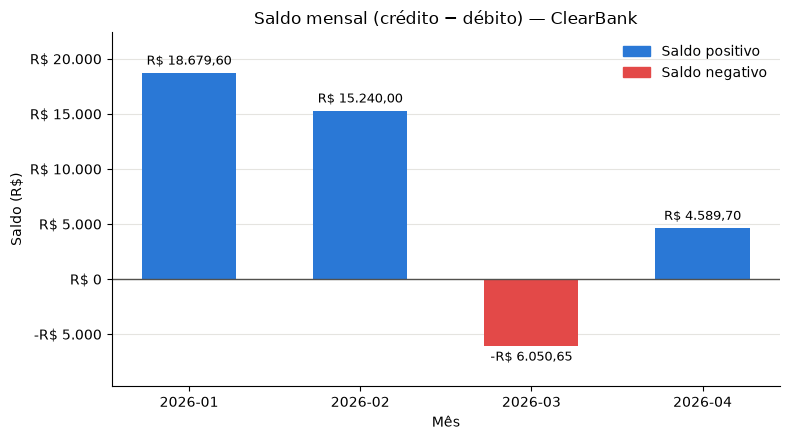

Gráfico salvo em 'grafico.png'.


In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COR_POSITIVO = "#2a78d6"
COR_NEGATIVO = "#e34948"


def gerar_grafico_saldo(relatorio, caminho="grafico.png"):
    """Gera e salva o gráfico de barras do saldo mensal."""
    meses = list(relatorio["resumo_mensal"])
    saldos = [m["saldo"] for m in relatorio["resumo_mensal"].values()]
    cores = [COR_POSITIVO if s >= 0 else COR_NEGATIVO for s in saldos]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    barras = ax.bar(meses, saldos, color=cores, width=0.55)
    ax.bar_label(barras, labels=[formatar_moeda(s) for s in saldos], padding=4, fontsize=9)
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.yaxis.set_major_formatter(lambda v, _: formatar_moeda(v).replace(",00", ""))
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(y=0.15)

    ax.set_title("Saldo mensal (crédito − débito) — ClearBank")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Saldo (R$)")
    ax.legend(handles=[Patch(color=COR_POSITIVO, label="Saldo positivo"),
                       Patch(color=COR_NEGATIVO, label="Saldo negativo")], frameon=False)

    fig.tight_layout()
    fig.savefig(caminho, dpi=150)
    plt.show()
    print(f"Gráfico salvo em '{caminho}'.")


gerar_grafico_saldo(relatorio)

## 9. (Opcional — RO1) Análise com pandas

A versão com pandas está no arquivo separado **`analise_pandas.py`** (`pd.read_csv` + `groupby`). Esta célula importa o módulo, roda a análise e compara o resumo mensal com o da solução nativa — os valores precisam ser iguais.

> No Colab, faça upload do `analise_pandas.py` para a mesma pasta antes de rodar esta célula.

In [20]:
if os.path.exists("analise_pandas.py"):
    import analise_pandas
    resumo_pandas = analise_pandas.main(CAMINHO_CSV, relatorio["resumo_mensal"])
else:
    print("Arquivo 'analise_pandas.py' não encontrado nesta pasta — faça o upload para rodar a comparação.")

===== ANÁLISE COM PANDAS =====
Linhas lidas: 30 | Válidas: 20 | Inválidas: 10

         quantidade  total_credito  total_debito     saldo    media  maior_valor  menor_valor
mes                                                                                          
2026-01           6        20200.0       1520.40  18679.60  3620.07      12500.0         89.9
2026-02           5        18500.0       3260.00  15240.00  4352.00      15000.0        320.0
2026-03           5         6300.0      12350.65  -6050.65  3730.13      11800.0         99.9
2026-04           4         6300.0       1710.30   4589.70  2002.58       3500.0        210.3

Comparação com a solução nativa: valores IGUAIS ✅
